# Physics-Informed Neural Networks — 2D Laplace & Heat Equation

A structured, pedagogical tour of PINNs from first principles to complex geometries.

**Roadmap**

| § | Topic | Key idea |
|---|-------|----------|
| 1 | Baseline — simple manual PINN | Minimal hardcoded PyTorch, square domain, u=1 on top |
| 2 | Hyperparameter study | Optimizers, depth, width, activations |
| 3 | Triangle-mesh sampling | Geometry-agnostic collocation |
| 4 | BC variants | Neumann, mixed, multi-mode |
| 5 | L-shaped domain | Non-convex geometry, FD reference |
| 6 | Transient heat equation | Full u_t = α∇²u with time |

All sections share a common analytical benchmark where one exists.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import time, warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')   # change to 'cuda' if available
print(f"PyTorch {torch.__version__} | device: {device}")


PyTorch 2.10.0 | device: cpu


---
## 1. Baseline — Simple Manual PINN

### Problem

Laplace (steady-state heat) equation on the unit square $[0,1]^2$:

$$\nabla^2 u \;=\; \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \;=\; 0$$

**Boundary conditions:**

| Boundary | Condition | Physical meaning |
|----------|-----------|-----------------|
| $x=0$ (left)   | $u = 0$ | cold wall |
| $x=1$ (right)  | $u = 0$ | cold wall |
| $y=0$ (bottom) | $u = 0$ | cold wall |
| $y=1$ (top)    | $u = 1$ | hot wall |

---

### Analytical Solution — Separation of Variables

**Step 1 — Assume a product form.**

Write $u(x,y) = X(x)\,Y(y)$ and substitute into $\nabla^2 u = 0$:

$$X''Y + XY'' = 0 \quad\Longrightarrow\quad \frac{X''}{X} = -\frac{Y''}{Y} = -\lambda^2$$

Because the left side depends only on $x$ and the right side only on $y$, both must equal the same constant $-\lambda^2$.

---

**Step 2 — Solve the $X$ equation.**

$$X'' + \lambda^2 X = 0, \qquad X(0) = 0,\quad X(1) = 0$$

General solution: $X(x) = A\sin(\lambda x) + B\cos(\lambda x)$.

- $X(0)=0 \;\Rightarrow\; B = 0$
- $X(1)=0 \;\Rightarrow\; \sin(\lambda) = 0 \;\Rightarrow\; \lambda_n = n\pi,\quad n=1,2,3,\ldots$

$$\boxed{X_n(x) = \sin(n\pi x)}$$

---

**Step 3 — Solve the $Y$ equation.**

$$Y'' - \lambda_n^2\, Y = 0, \qquad Y(0) = 0$$

General solution: $Y(y) = C\sinh(\lambda_n y) + D\cosh(\lambda_n y)$.

- $Y(0)=0 \;\Rightarrow\; D = 0$

$$\boxed{Y_n(y) = \sinh(n\pi y)}$$

There is no condition at $y=1$ yet — that BC will determine the coefficients.

---

**Step 4 — General solution (superposition).**

By linearity, the general solution satisfying the three homogeneous BCs is:

$$u(x,y) = \sum_{n=1}^{\infty} B_n \sin(n\pi x)\,\sinh(n\pi y)$$

---

**Step 5 — Apply the non-homogeneous BC at $y=1$.**

$$u(x,1) = 1 \quad\Longrightarrow\quad \sum_{n=1}^{\infty} B_n\,\sinh(n\pi)\,\sin(n\pi x) = 1$$

This is a Fourier sine series on $[0,1]$. The coefficients are:

$$B_n\,\sinh(n\pi) = 2\int_0^1 1 \cdot \sin(n\pi x)\,dx = \frac{2}{n\pi}\bigl[-\cos(n\pi x)\bigr]_0^1 = \frac{2(1 - \cos(n\pi))}{n\pi}$$

Since $\cos(n\pi) = (-1)^n$:

$$B_n\,\sinh(n\pi) = \begin{cases} \dfrac{4}{n\pi} & n \text{ odd} \\[6pt] 0 & n \text{ even} \end{cases}$$

$$\therefore\quad B_n = \frac{4}{n\pi\,\sinh(n\pi)}, \qquad n = 1, 3, 5, \ldots$$

---

**Step 6 — Final solution.**

$$\boxed{u(x,y) \;=\; \sum_{\substack{n=1,3,5,\ldots}} \frac{4}{n\pi} \cdot \frac{\sin(n\pi x)\,\sinh(n\pi y)}{\sinh(n\pi)}}$$

The series converges very rapidly because $\sinh(n\pi)$ grows exponentially with $n$ — in practice $N = 20$ terms is more than sufficient.


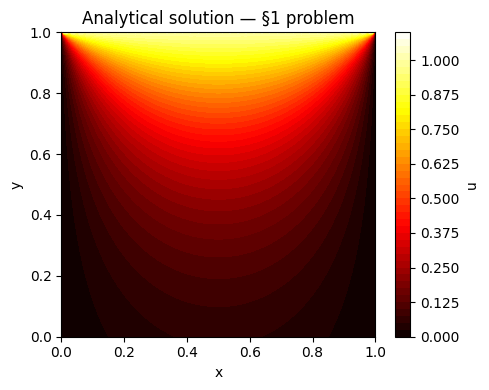

u at centre (0.5, 0.5) = 0.26096


In [2]:
def u_exact_p1(x, y, N=40):
    '''
    Fourier-series solution for Laplace on [0,1]^2:
      u=0 on left, right, bottom;  u=1 on top.
    Converges very fast (sinh grows exponentially).
    '''
    u = np.zeros_like(x, dtype=float)
    for n in range(1, 2*N, 2):          # odd n only
        Bn = 4.0 / (n * np.pi)  # sinh(nπ) absorbed into exp form below
        # Use exp form for numerical stability: sinh(nπy)/sinh(nπ) ≈ exp(nπ(y−1))
        u += Bn * np.sin(n * np.pi * x) * np.exp(n * np.pi * (y - 1.0))
    return u

# Quick visualisation of the exact solution
x1d = np.linspace(0, 1, 120)
y1d = np.linspace(0, 1, 120)
XX, YY = np.meshgrid(x1d, y1d)
U_exact = u_exact_p1(XX, YY)

plt.figure(figsize=(5, 4))
plt.contourf(XX, YY, U_exact, levels=50, cmap='hot')
plt.colorbar(label='u')
plt.title('Analytical solution — §1 problem', fontsize=12)
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

print(f"u at centre (0.5, 0.5) = {u_exact_p1(np.array([0.5]), np.array([0.5]))[0]:.5f}")


### Simple Manual PINN

We build the smallest possible PINN — everything hardcoded, no abstractions — to make the structure fully transparent.

**Network:** $\hat u_\theta(x,y)$ — 3 hidden layers × 32 neurons, Tanh activation.

---

### Loss Function

The network is trained by minimising a weighted sum of three terms:

$$\boxed{\mathcal{L}(\theta) \;=\; w_{\text{pde}}\,\mathcal{L}_{\text{pde}} \;+\; w_{\text{bc}}\,\mathcal{L}_{\text{bc}} \;+\; w_{\text{data}}\,\mathcal{L}_{\text{data}}}$$

| Term | Formula | Role |
|------|---------|------|
| $\mathcal{L}_{\text{pde}}$ | $\dfrac{1}{N_{\text{pde}}}\displaystyle\sum_{i=1}^{N_{\text{pde}}} \!\bigl(\hat u_{xx}(\mathbf{x}_i) + \hat u_{yy}(\mathbf{x}_i)\bigr)^2$ | Enforce the PDE at random interior collocation points |
| $\mathcal{L}_{\text{bc}}$ | $\dfrac{1}{N_{\text{bc}}}\displaystyle\sum_{j=1}^{N_{\text{bc}}} \!\bigl(\hat u(\mathbf{x}_j) - u^*_j\bigr)^2$ | Enforce Dirichlet values at boundary points |
| $\mathcal{L}_{\text{data}}$ | $\dfrac{1}{N_{\text{data}}}\displaystyle\sum_{k=1}^{N_{\text{data}}} \!\bigl(\hat u(\mathbf{x}_k) - u^{\text{obs}}_k\bigr)^2$ | Match known solution values at sparse interior observation points |

**Weights used:** $w_{\text{pde}} = 1$, $\;\;w_{\text{bc}} = 20$, $\;\;w_{\text{data}} = 10$.

Higher BC and data weights ensure the network satisfies the imposed values accurately before the PDE residual is minimised.

---

**Automatic differentiation** computes $\hat u_{xx}$ and $\hat u_{yy}$ exactly through the network graph — no finite differences needed.

The $N_{\text{data}}$ **interior observation points** are sampled from the analytical solution and held fixed throughout training. In a real physical problem these would be sensor or measurement locations. In fact, one could add noise here to mimic sensor readings. For now we keep the data "clean".


In [3]:
# ── Network ────────────────────────────────────────────────────────────────────
# 2 interior layers, 32 nuerons per each
class SimplePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, xy):          # xy : (N, 2)
        return self.net(xy).squeeze(-1)


# ── PDE loss (Laplace residual) ────────────────────────────────────────────────
def laplace_residual(model, x, y):
    '''Returns mean squared PDE residual u_xx + u_yy at interior points.'''
    x = x.clone().requires_grad_(True)
    y = y.clone().requires_grad_(True)
    u  = model(torch.stack([x, y], dim=1))
    u_x  = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
    u_y  = torch.autograd.grad(u.sum(), y, create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y.sum(), y, create_graph=True)[0]
    return (u_xx + u_yy).pow(2).mean()


# ── BC loss for Problem 1 ──────────────────────────────────────────────────────
# Hard coding the BCs here -- needs to be configured better for real problems 
def bc_loss_p1(model, n=300):
    '''u=0 on left/right/bottom, u=1 on top.'''
    losses = []
    for xi, yi, target in [
        (torch.rand(n),   torch.zeros(n), 0.0),   # bottom
        (torch.zeros(n),  torch.rand(n),  0.0),   # left
        (torch.ones(n),   torch.rand(n),  0.0),   # right
        (torch.rand(n),   torch.ones(n),  1.0),   # top
    ]:
        pred = model(torch.stack([xi, yi], dim=1))
        losses.append((pred - target).pow(2).mean())
    return sum(losses) / len(losses)


# ── Data loss (sparse interior observations) ───────────────────────────────────
def sample_data_p1(n=50, seed=7):
    '''
    Draw n random interior points and label them with the analytical solution.
    Simulates sparse sensor measurements inside the domain.
    '''
    rng = np.random.default_rng(seed)
    x = rng.uniform(0.05, 0.95, n).astype(np.float32)
    y = rng.uniform(0.05, 0.95, n).astype(np.float32)
    u = u_exact_p1(x, y).astype(np.float32)
    return (torch.tensor(x), torch.tensor(y), torch.tensor(u))

def data_loss(model, x_d, y_d, u_d):
    '''MSE between network prediction and known values at interior data points.'''
    pred = model(torch.stack([x_d, y_d], dim=1))
    return (pred - u_d).pow(2).mean()


# ── Generate fixed data points (used throughout §1) ───────────────────────────
X_DATA, Y_DATA, U_DATA = sample_data_p1(n=50)
print(f"Data points: {len(X_DATA)}  |  u range [{U_DATA.min():.3f}, {U_DATA.max():.3f}]")
# ── Helper: L2 error vs analytical (defined early; also used in §2) ───────────
def eval_model(model, nx=100):
    x1d = np.linspace(0, 1, nx)
    y1d = np.linspace(0, 1, nx)
    XX_e, YY_e = np.meshgrid(x1d, y1d)
    xy = torch.tensor(np.stack([XX_e.ravel(), YY_e.ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        U_pred = model(xy).numpy().reshape(nx, nx)
    return XX_e, YY_e, U_pred

def l2_error(model, exact_fn, nx=80):
    x1d = np.linspace(0, 1, nx)
    y1d = np.linspace(0, 1, nx)
    XX_e, YY_e = np.meshgrid(x1d, y1d)
    xy = torch.tensor(np.stack([XX_e.ravel(), YY_e.ravel()], 1), dtype=torch.float32)
    with torch.no_grad():
        U_pred = model(xy).numpy().reshape(nx, nx)
    U_true = exact_fn(XX_e, YY_e)
    return np.sqrt(((U_pred - U_true)**2).mean()) / np.sqrt((U_true**2).mean() + 1e-12)


Data points: 50  |  u range [0.022, 0.834]


In [4]:
# ── Training ───────────────────────────────────────────────────────────────────
model_simple = SimplePINN()
# Start with Adam optimizer (commonly used), learning rate is constant
# Questions I'd have --> is Adam best? Constant learning rate does what? 
optimizer    = torch.optim.Adam(model_simple.parameters(), lr=1e-3)

# How do we decide these weights...can we make them dynamic or does that redefine the problem
W_PDE, W_BC, W_DATA = 1.0, 20.0, 10.0
N_PDE, N_BC         = 2000, 400
EPOCHS              = 5000

hist_simple = {'pde': [], 'bc': [], 'data': [], 'total': []}
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    x_i = torch.rand(N_PDE)
    y_i = torch.rand(N_PDE)

    lp = laplace_residual(model_simple, x_i, y_i)
    lb = bc_loss_p1(model_simple, N_BC)
    ld = data_loss(model_simple, X_DATA, Y_DATA, U_DATA)

    loss = W_PDE * lp + W_BC * lb + W_DATA * ld
    loss.backward()
    optimizer.step()

    hist_simple['pde'].append(lp.item())
    hist_simple['bc'].append(lb.item())
    hist_simple['data'].append(ld.item())
    hist_simple['total'].append(loss.item())

    if ep % 1000 == 0:
        print(f"Epoch {ep:5d} | total {loss.item():.3e} | "
              f"pde {lp.item():.3e} | bc {lb.item():.3e} | data {ld.item():.3e}")

print(f"\nTraining time: {time.time()-t0:.1f}s")


Epoch  1000 | total 5.731e-01 | pde 2.111e-02 | bc 2.724e-02 | data 7.149e-04
Epoch  2000 | total 4.838e-01 | pde 7.456e-03 | bc 2.337e-02 | data 8.931e-04
Epoch  3000 | total 4.349e-01 | pde 1.023e-02 | bc 2.088e-02 | data 7.103e-04
Epoch  4000 | total 3.906e-01 | pde 1.401e-02 | bc 1.862e-02 | data 4.172e-04
Epoch  5000 | total 3.225e-01 | pde 1.369e-02 | bc 1.526e-02 | data 3.650e-04

Training time: 29.0s


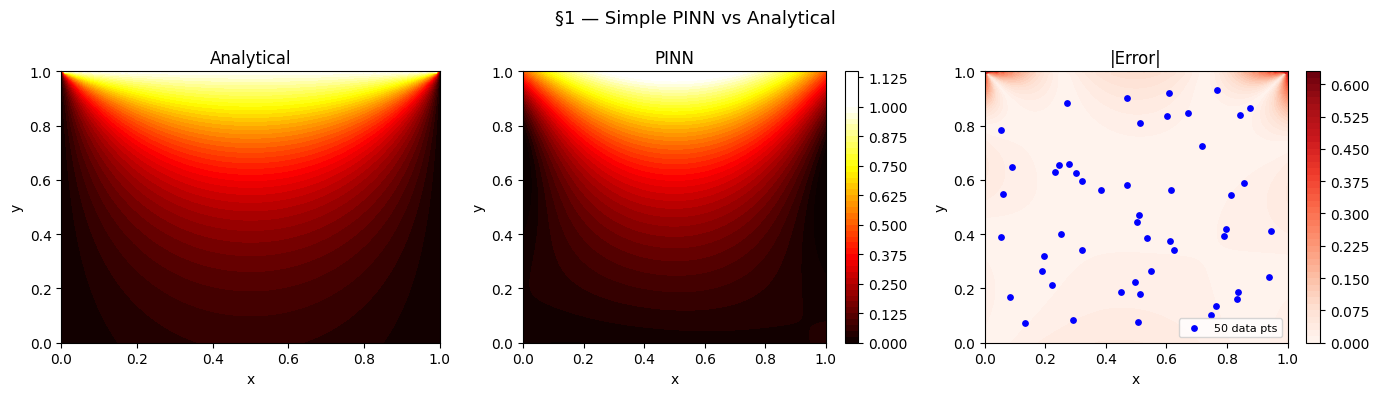

Relative L2 error: 10.4445%


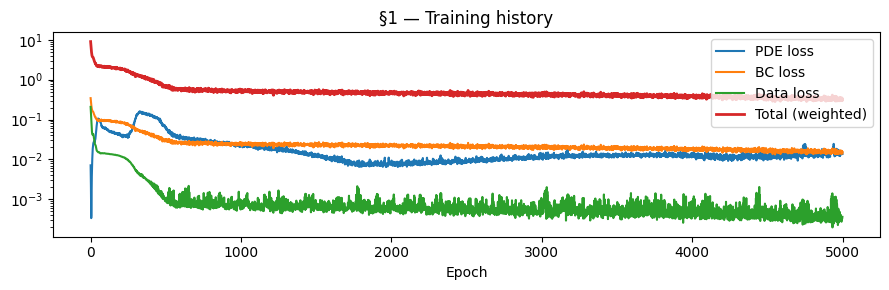

In [5]:
# ── Evaluation ─────────────────────────────────────────────────────────────────
XX, YY, U_pred_simple = eval_model(model_simple)
U_true = u_exact_p1(XX, YY)
err    = np.abs(U_pred_simple - U_true)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(vmin=0, vmax=1, cmap='hot', levels=50)
c0 = axes[0].contourf(XX, YY, U_true,        **kw); axes[0].set_title('Analytical')
c1 = axes[1].contourf(XX, YY, U_pred_simple, **kw); axes[1].set_title('PINN')
c2 = axes[2].contourf(XX, YY, err, levels=50, cmap='Reds'); axes[2].set_title('|Error|')

# Overlay data points on error map
axes[2].scatter(X_DATA.numpy(), Y_DATA.numpy(), c='blue', s=15,
                zorder=5, label=f'{len(X_DATA)} data pts')
axes[2].legend(loc='lower right', fontsize=8)

for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
fig.colorbar(c0, ax=axes[1]); fig.colorbar(c2, ax=axes[2])
plt.suptitle('§1 — Simple PINN vs Analytical', fontsize=13)
plt.tight_layout(); plt.show()

l2_rel = np.sqrt(((U_pred_simple-U_true)**2).mean()) / np.sqrt((U_true**2).mean())
print(f"Relative L2 error: {l2_rel:.4%}")

# Loss curves
fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(hist_simple['pde'],   label='PDE loss')
ax.semilogy(hist_simple['bc'],    label='BC loss')
ax.semilogy(hist_simple['data'],  label='Data loss')
ax.semilogy(hist_simple['total'], label='Total (weighted)', lw=2)
ax.set_xlabel('Epoch'); ax.legend(); ax.set_title('§1 — Training history')
plt.tight_layout(); plt.show()


---
### 1b. Choosing Loss Weights

The total loss is a weighted sum, and the **choice of weights strongly affects training**.
There is no universal rule, but several principled strategies exist:

| Strategy | Formula | Intuition |
|----------|---------|-----------|
| **Equal** | $w_k = 1$ | Simple baseline; usually under-enforces BCs |
| **Manual tuning** | Try $w_{\text{bc}} \sim 10{-}100\times w_{\text{pde}}$ | BCs are cheap to satisfy — anchor them first |
| **Initial-loss scaling** | $w_k = 1\,/\,\mathcal{L}_k(\theta_0)$ | Normalises all terms to ≈1 at epoch 0 |
| **Gradient-norm balancing** | $w_k \propto \|\nabla_\theta \mathcal{L}_{\text{total}}\|\,/\,\|\nabla_\theta \mathcal{L}_k\|$ | Equalises each term's contribution to the gradient |
| **Self-adaptive (learnable)** | Treat $w_k$ as softmax-parameterised variables, train jointly | Elegant but can be unstable |

**Why BCs need a larger weight:**
The PDE loss involves second-order derivatives — these gradients are noisy and small at
initialisation. If all weights are equal the network sees a small PDE gradient signal
that can overwhelm the BC signal, leaving boundary conditions poorly satisfied.
Giving BCs (and data) a higher weight anchors the solution early, after which the
PDE residual has a stable function to refine.

The experiment below tests five weight combinations and compares the resulting
training dynamics and final accuracy.


Equal  (1:1:1)          PDE 3.997e-04  BC err 0.1769  L2 13.6988%
Low BC (1:5:5)          PDE 2.411e-03  BC err 0.1675  L2 13.7317%
Ours   (1:20:10)        PDE 1.401e-02  BC err 0.1504  L2 12.5245%
High BC(1:100:50)       PDE 9.230e-02  BC err 0.1137  L2 11.1166%
Init-scaled weights:  w_pde=1  w_bc=0.0  w_data=0.0
Init-scaled             PDE 3.188e-05  BC err 0.1571  L2 18.6832%


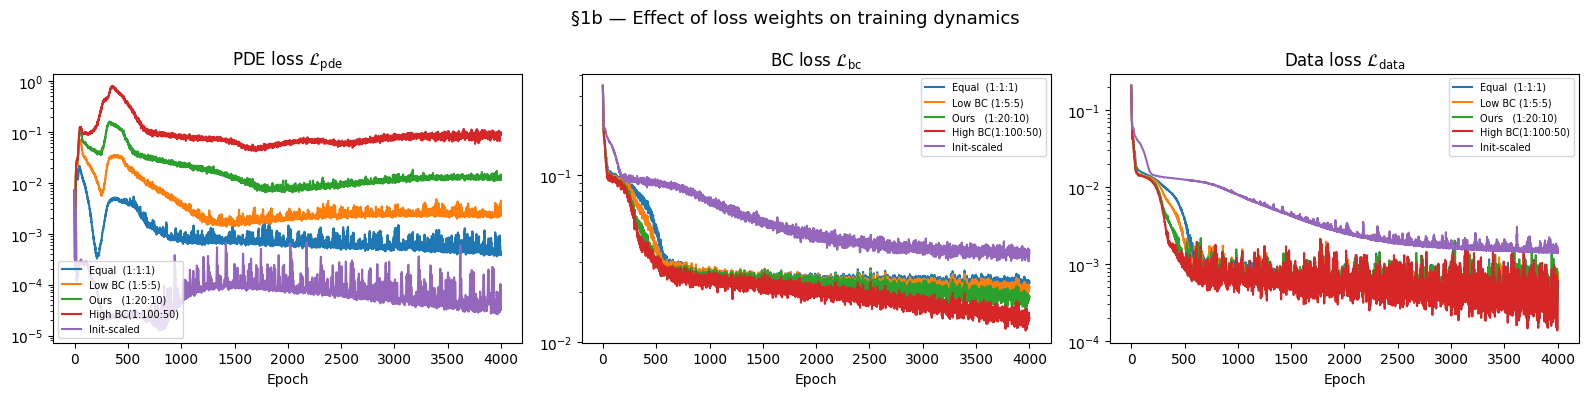

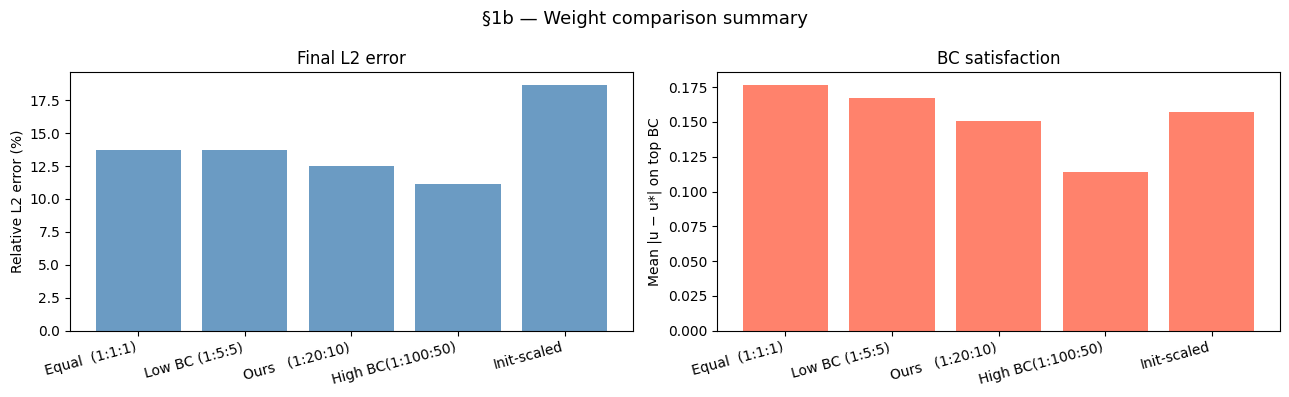

In [6]:
# ── Weight sensitivity experiment ──────────────────────────────────────────────
# We keep the same architecture and epoch count; only the loss weights change.

weight_configs = {
    'Equal  (1:1:1)':       dict(w_pde=1.0,  w_bc=1.0,   w_data=1.0),
    'Low BC (1:5:5)':       dict(w_pde=1.0,  w_bc=5.0,   w_data=5.0),
    'Ours   (1:20:10)':     dict(w_pde=1.0,  w_bc=20.0,  w_data=10.0),
    'High BC(1:100:50)':    dict(w_pde=1.0,  w_bc=100.0, w_data=50.0),
    'Init-scaled':          None,   # handled separately below
}

EPOCHS_W   = 4000
DATA_PTS_W = (X_DATA, Y_DATA, U_DATA)
results_w  = {}

for label, wcfg in weight_configs.items():
    torch.manual_seed(42)
    m = SimplePINN()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)

    if wcfg is None:
        # ── Initial-loss scaling: run one forward pass to get L_k(θ_0) ──────
        # Note: laplace_residual needs autograd — cannot use torch.no_grad()
        lp0 = laplace_residual(m, torch.rand(500), torch.rand(500)).item()
        with torch.no_grad():
            lb0 = bc_loss_p1(m, 200).item()
            ld0 = data_loss(m, *DATA_PTS_W).item()
        wp = 1.0 / (lp0 + 1e-8)
        wb = 1.0 / (lb0 + 1e-8)
        wd = 1.0 / (ld0 + 1e-8)
        # Normalise so w_pde = 1
        wb /= wp;  wd /= wp;  wp = 1.0
        print(f"Init-scaled weights:  w_pde=1  w_bc={wb:.1f}  w_data={wd:.1f}")
        wcfg = dict(w_pde=wp, w_bc=wb, w_data=wd)

    wp, wb, wd = wcfg['w_pde'], wcfg['w_bc'], wcfg['w_data']
    h = {'pde': [], 'bc': [], 'data': [], 'total': []}

    for ep in range(EPOCHS_W):
        opt.zero_grad()
        lp = laplace_residual(m, torch.rand(2000), torch.rand(2000))
        lb = bc_loss_p1(m, 400)
        ld = data_loss(m, *DATA_PTS_W)
        loss = wp*lp + wb*lb + wd*ld
        loss.backward(); opt.step()
        h['pde'].append(lp.item()); h['bc'].append(lb.item())
        h['data'].append(ld.item()); h['total'].append(loss.item())

    err = l2_error(m, u_exact_p1)
    # also measure BC satisfaction: mean |u - u*| on boundaries
    with torch.no_grad():
        xb = torch.rand(400); yb_top = torch.ones(400)
        bc_err = (m(torch.stack([xb, yb_top], 1)) - 1).abs().mean().item()
    results_w[label] = {'hist': h, 'l2': err, 'bc_err': bc_err}
    print(f"{label:22s}  PDE {h['pde'][-1]:.3e}  BC err {bc_err:.4f}  L2 {err:.4%}")

# ── Plots ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, res in results_w.items():
    axes[0].semilogy(res['hist']['pde'],  label=label)
    axes[1].semilogy(res['hist']['bc'],   label=label)
    axes[2].semilogy(res['hist']['data'], label=label)

axes[0].set_title('PDE loss $\mathcal{L}_\mathrm{pde}$')
axes[1].set_title('BC loss $\mathcal{L}_\mathrm{bc}$')
axes[2].set_title('Data loss $\mathcal{L}_\mathrm{data}$')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(fontsize=7)
plt.suptitle('§1b — Effect of loss weights on training dynamics', fontsize=13)
plt.tight_layout(); plt.show()

# ── Summary bar chart ───────────────────────────────────────────────────────────
labels  = list(results_w.keys())
l2s     = [results_w[k]['l2']     for k in labels]
bc_errs = [results_w[k]['bc_err'] for k in labels]

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(x, [v*100 for v in l2s], color='steelblue', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha='right')
axes[0].set_ylabel('Relative L2 error (%)'); axes[0].set_title('Final L2 error')

axes[1].bar(x, bc_errs, color='tomato', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].set_ylabel('Mean |u − u*| on top BC'); axes[1].set_title('BC satisfaction')

plt.suptitle('§1b — Weight comparison summary', fontsize=13)
plt.tight_layout(); plt.show()


---
## 2. Hyperparameter Study

We now use a **configurable PINN** to systematically explore:

1. **Optimizers** — Adam, Adam → L-BFGS, RMSprop
2. **Depth** — 2, 3, 4, 6 hidden layers
3. **Width** — 16, 32, 64, 128 neurons
4. **Activations** — Tanh, Sin, GELU, SiLU

For each experiment we run the same number of epochs and compare:
- Final **PDE loss** (residual)
- Final **relative L2 error** against the analytical solution
- **Convergence speed**


In [7]:
# ── Configurable PINN ──────────────────────────────────────────────────────────
class PINN(nn.Module):
    '''
    Fully-connected PINN for 2D steady-state problems.

    Parameters
    ----------
    n_in   : input dimension (2 for steady, 3 for transient)
    hidden : list of hidden layer widths
    act    : activation class (nn.Tanh, nn.GELU, ...)
    '''
    def __init__(self, n_in=2, hidden=[64, 64, 64], act=nn.Tanh):
        super().__init__()
        dims = [n_in] + hidden + [1]
        layers = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), act()]
        layers.pop()                     # remove last activation
        self.net = nn.Sequential(*layers)

    def forward(self, xy):
        return self.net(xy).squeeze(-1)


# ── Generic training function ──────────────────────────────────────────────────
def train_pinn(model, pde_loss_fn, bc_loss_fn,
               n_epochs=4000, lr=1e-3,
               n_pde=2000, n_bc=400,
               w_pde=1.0, w_bc=20.0,
               data_pts=None, w_data=10.0,
               lbfgs_steps=0, verbose=False):
    '''
    Train with Adam (and optionally L-BFGS fine-tuning).

    data_pts : tuple (x_d, y_d, u_d) of known interior observations, or None.
    Returns history dict with keys pde, bc, data (if used), total.
    '''
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    use_data = data_pts is not None
    hist = {'pde': [], 'bc': [], 'total': []}
    if use_data:
        hist['data'] = []

    for ep in range(1, n_epochs + 1):
        opt.zero_grad()
        x_i, y_i = torch.rand(n_pde), torch.rand(n_pde)
        lp = pde_loss_fn(model, x_i, y_i)
        lb = bc_loss_fn(model, n_bc)
        loss = w_pde * lp + w_bc * lb
        if use_data:
            ld = data_loss(model, *data_pts)
            loss = loss + w_data * ld
            hist['data'].append(ld.item())
        loss.backward()
        opt.step()
        hist['pde'].append(lp.item())
        hist['bc'].append(lb.item())
        hist['total'].append(loss.item())
        if verbose and ep % 1000 == 0:
            data_str = f" | data {ld.item():.3e}" if use_data else ""
            print(f"  Adam ep {ep:5d} | pde {lp.item():.3e} | bc {lb.item():.3e}{data_str}")

    if lbfgs_steps > 0:
        opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5,
                                       max_iter=20, history_size=50,
                                       line_search_fn='strong_wolfe')
        for step in range(lbfgs_steps):
            def closure():
                opt_lbfgs.zero_grad()
                x_i, y_i = torch.rand(n_pde), torch.rand(n_pde)
                lp = pde_loss_fn(model, x_i, y_i)
                lb = bc_loss_fn(model, n_bc)
                loss = w_pde * lp + w_bc * lb
                if use_data:
                    loss = loss + w_data * data_loss(model, *data_pts)
                loss.backward()
                return loss
            opt_lbfgs.step(closure)
            # Recompute losses for logging (no_grad skipped: bc may need autograd for Neumann BCs)
            lp = pde_loss_fn(model, torch.rand(n_pde), torch.rand(n_pde))
            lb = bc_loss_fn(model, n_bc)
            ld = data_loss(model, *data_pts) if use_data else torch.tensor(0.0)
            hist['pde'].append(lp.item())
            hist['bc'].append(lb.item())
            hist['total'].append((w_pde*lp + w_bc*lb + (w_data*ld if use_data else 0)).item())
            if use_data: hist['data'].append(ld.item())
            if verbose and (step+1) % 100 == 0:
                print(f"  L-BFGS step {step+1:4d} | pde {lp.item():.3e} | bc {lb.item():.3e}")

    return hist




# ── Fixed data points for §2 experiments (same 50 points as §1) ───────────────
# X_DATA, Y_DATA, U_DATA are already defined in §1.
print("Configurable PINN and train_pinn ready.")
print(f"Data points available: {len(X_DATA)}")


Configurable PINN and train_pinn ready.
Data points available: 50


### Loss Function (all experiments)

Every experiment in this section uses the **same three-term loss** and the **same 50 fixed interior observations** (`X_DATA`, `Y_DATA`, `U_DATA`) generated in §1:

$$\mathcal{L}(\theta) \;=\; \underbrace{w_{\text{pde}}\,\mathcal{L}_{\text{pde}}}_{\text{physics}} \;+\; \underbrace{w_{\text{bc}}\,\mathcal{L}_{\text{bc}}}_{\text{boundary}} \;+\; \underbrace{w_{\text{data}}\,\mathcal{L}_{\text{data}}}_{\text{observations}}$$

$$w_{\text{pde}} = 1, \qquad w_{\text{bc}} = 20, \qquad w_{\text{data}} = 10$$

Fixing these weights isolates the effect of each hyperparameter (optimizer / architecture / activation) on training dynamics and final accuracy.


Adam             PDE 1.121e-02  data 3.667e-04  L2 12.1367%
Adam->L-BFGS     PDE 9.956e-03  data 3.582e-04  L2 11.5979%
RMSprop          PDE 5.696e-02  data 1.153e-03  L2 13.7510%


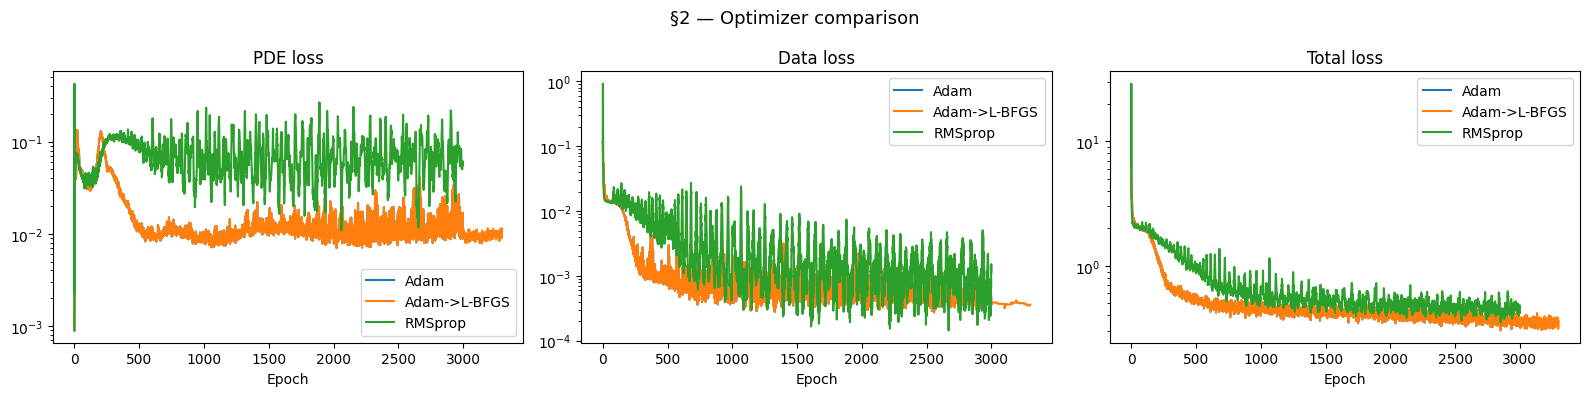

In [8]:
# ── Experiment 1: Optimizers ───────────────────────────────────────────────────
torch.manual_seed(0)

experiments_opt = {
    'Adam':         {},
    'Adam->L-BFGS': {'lbfgs_steps': 300},
    'RMSprop':      None,   # handled separately
}

results_opt = {}
EPOCHS_OPT  = 3000
DATA_PTS    = (X_DATA, Y_DATA, U_DATA)

for key in experiments_opt:
    torch.manual_seed(0)
    m = PINN(hidden=[64, 64, 64])

    if key == 'RMSprop':
        opt_r = torch.optim.RMSprop(m.parameters(), lr=1e-3)
        h = {'pde': [], 'bc': [], 'data': [], 'total': []}
        for ep in range(EPOCHS_OPT):
            opt_r.zero_grad()
            x_i, y_i = torch.rand(2000), torch.rand(2000)
            lp = laplace_residual(m, x_i, y_i)
            lb = bc_loss_p1(m, 400)
            ld = data_loss(m, *DATA_PTS)
            loss = 1.0*lp + 20.0*lb + 10.0*ld
            loss.backward(); opt_r.step()
            h['pde'].append(lp.item()); h['bc'].append(lb.item())
            h['data'].append(ld.item()); h['total'].append(loss.item())
    else:
        extra = experiments_opt[key] or {}
        h = train_pinn(m, laplace_residual, bc_loss_p1,
                       n_epochs=EPOCHS_OPT, lr=1e-3,
                       data_pts=DATA_PTS, **extra)

    err = l2_error(m, u_exact_p1)
    results_opt[key] = {'hist': h, 'l2': err}
    print(f"{key:15s}  PDE {h['pde'][-1]:.3e}  data {h['data'][-1]:.3e}  L2 {err:.4%}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for key, res in results_opt.items():
    axes[0].semilogy(res['hist']['pde'],   label=key)
    axes[1].semilogy(res['hist']['data'],  label=key)
    axes[2].semilogy(res['hist']['total'], label=key)
axes[0].set_title('PDE loss'); axes[1].set_title('Data loss'); axes[2].set_title('Total loss')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('§2 — Optimizer comparison', fontsize=13)
plt.tight_layout(); plt.show()


2x32      params   1185  PDE 7.750e-03  L2 12.7347%
3x64      params   8577  PDE 1.121e-02  L2 12.1367%
4x64      params  12737  PDE 1.018e-02  L2 12.3165%
4x128     params  50049  PDE 4.317e-02  L2 9.3293%
6x64      params  21057  PDE 7.812e-03  L2 13.1020%


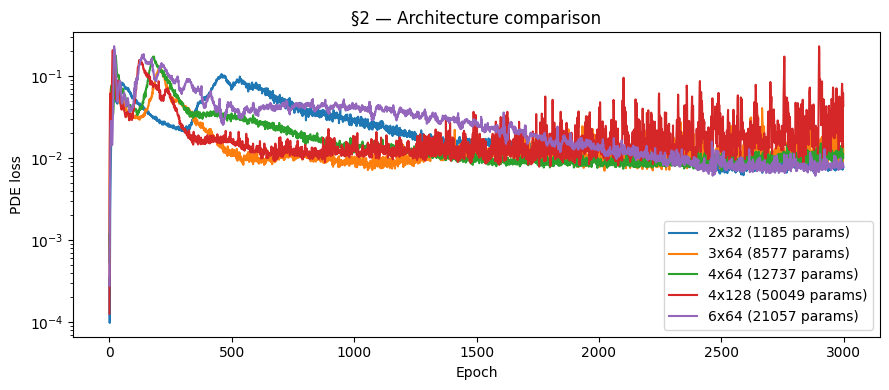

In [9]:
# ── Experiment 2: Depth & Width ────────────────────────────────────────────────
torch.manual_seed(0)
DATA_PTS = (X_DATA, Y_DATA, U_DATA)

arch_configs = {
    '2x32':  [32, 32],
    '3x64':  [64, 64, 64],
    '4x64':  [64, 64, 64, 64],
    '4x128': [128, 128, 128, 128],
    '6x64':  [64]*6,
}

results_arch = {}
for key, hidden in arch_configs.items():
    torch.manual_seed(0)
    m = PINN(hidden=hidden)
    h = train_pinn(m, laplace_residual, bc_loss_p1,
                   n_epochs=3000, lr=1e-3, data_pts=DATA_PTS)
    err = l2_error(m, u_exact_p1)
    n_params = sum(p.numel() for p in m.parameters())
    results_arch[key] = {'hist': h, 'l2': err, 'params': n_params}
    print(f"{key:8s}  params {n_params:6d}  PDE {h['pde'][-1]:.3e}  L2 {err:.4%}")

fig, ax = plt.subplots(figsize=(9, 4))
for key, res in results_arch.items():
    ax.semilogy(res['hist']['pde'], label=f"{key} ({res['params']} params)")
ax.set_xlabel('Epoch'); ax.set_ylabel('PDE loss')
ax.set_title('§2 — Architecture comparison'); ax.legend()
plt.tight_layout(); plt.show()


#### Why Tanh? — Activation Functions in PINNs

The choice of activation matters more in PINNs than in standard deep learning,
because the network must be **differentiated through** to compute the PDE residual.

| Activation | $C^\infty$ smooth? | 2nd deriv non-zero? | Good for PINNs? | Notes |
|---|:---:|:---:|:---:|---|
| **ReLU** | ✗ | ✗ (zero a.e.) | ✗ | Piecewise-linear — $\hat u_{xx} \equiv 0$, PDE loss carries no gradient |
| **Tanh** | ✓ | ✓ | ✓✓ | Default choice: stable, bounded $(-1,1)$, smooth derivatives throughout |
| **Sin (SIREN)** | ✓ | ✓ | ✓✓ | Natural for Fourier-type solutions; init-sensitive, can get stuck |
| **GELU / SiLU** | ✓ | ✓ | ✓ | Smooth ReLU approximations; competitive but less studied for PINNs |
| **ELU** | ✓ | ✓ | ✓ | Smooth alternative to tanh; similar empirical performance |

**Why Tanh specifically:**

1. **Infinite differentiability** — $\tanh$ is $C^\infty$, so autograd can propagate through any order of derivative without hitting zeros.
2. **Non-zero second derivative** — $\tanh''(x) = -2\tanh(x)\,\mathrm{sech}^2(x)$, which is non-zero almost everywhere. This is the minimum requirement for the PDE loss to be informative.
3. **Smooth solutions need smooth networks** — the Laplace/heat equation solutions are analytic functions. Tanh networks have the right inductive bias; ReLU networks represent piecewise-linear functions, a poor fit.
4. **Bounded activations** — outputs in $(-1,1)$ prevent blow-up in deep networks without batch normalisation, which would interfere with the autograd differentiation chain.
5. **Symmetric (odd function)** — $\tanh(-x) = -\tanh(x)$, consistent with the symmetry of many PDE solutions.

**Why Sin (SIREN) is also compelling:**
Our analytical solution *is* a Fourier sine series — so sin activations give the
network a natural basis that exactly matches the solution structure.
The catch: SIREN networks require a careful initialisation scheme
(weights $\sim U(-\sqrt{6/n}, \sqrt{6/n})$) and can be harder to optimise.


Tanh    PDE 1.121e-02  L2 12.1367%
Sin     PDE 3.167e-02  L2 12.3878%
GELU    PDE 1.955e-02  L2 7.4299%
SiLU    PDE 1.061e-02  L2 12.6207%


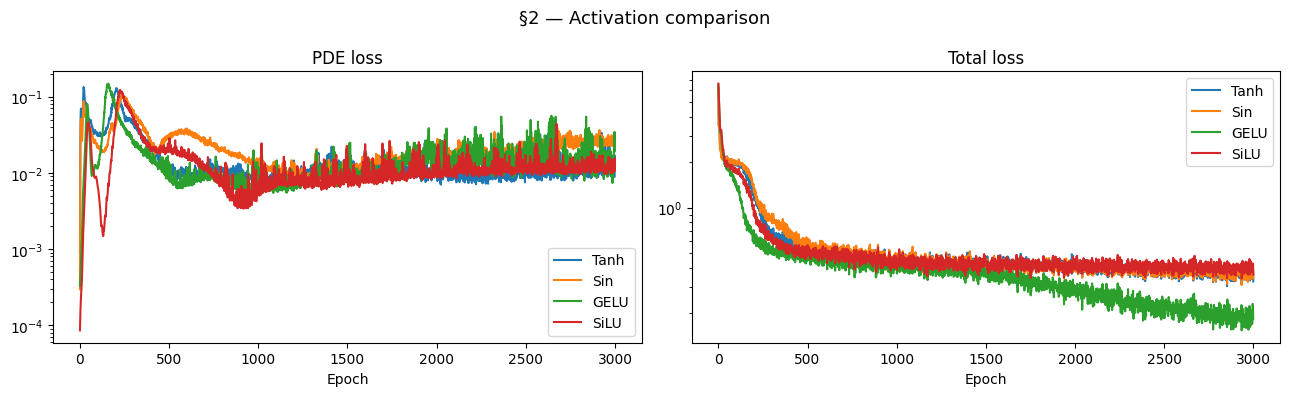

In [10]:
# ── Experiment 3: Activations ──────────────────────────────────────────────────
torch.manual_seed(0)
DATA_PTS = (X_DATA, Y_DATA, U_DATA)

class Sin(nn.Module):
    def forward(self, x): return torch.sin(x)

act_configs = {
    'Tanh': nn.Tanh,
    'Sin':  Sin,
    'GELU': nn.GELU,
    'SiLU': nn.SiLU,
}

results_act = {}
for key, act in act_configs.items():
    torch.manual_seed(0)
    m = PINN(hidden=[64, 64, 64], act=act)
    h = train_pinn(m, laplace_residual, bc_loss_p1,
                   n_epochs=3000, lr=1e-3, data_pts=DATA_PTS)
    err = l2_error(m, u_exact_p1)
    results_act[key] = {'hist': h, 'l2': err}
    print(f"{key:6s}  PDE {h['pde'][-1]:.3e}  L2 {err:.4%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for key, res in results_act.items():
    axes[0].semilogy(res['hist']['pde'],   label=key)
    axes[1].semilogy(res['hist']['total'], label=key)
axes[0].set_title('PDE loss'); axes[1].set_title('Total loss')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('§2 — Activation comparison', fontsize=13)
plt.tight_layout(); plt.show()


### Summary

From the experiments above we can observe:

- **Optimizer**: Adam → L-BFGS typically gives the lowest PDE residual. Adam alone is usually sufficient for BC fitting, but L-BFGS excels at minimising the smooth PDE residual to machine precision.
- **Depth vs Width**: Deeper networks (4–6 layers) reduce the PDE residual better than wide shallow ones for the same parameter budget.
- **Activation**: `sin` and `Tanh` work best for smooth PDE solutions; `GELU`/`SiLU` can be competitive but occasionally get stuck.

We'll use **4 × 64 + Tanh + Adam → L-BFGS** as our standard config going forward.


  Adam ep  1000 | pde 1.718e-02 | bc 1.705e-02 | data 7.368e-04
  Adam ep  2000 | pde 1.270e-02 | bc 9.115e-03 | data 1.305e-04
  Adam ep  3000 | pde 2.178e-02 | bc 7.378e-03 | data 1.212e-04
  Adam ep  4000 | pde 1.974e-02 | bc 6.173e-03 | data 2.014e-04
  Adam ep  5000 | pde 1.367e-02 | bc 6.886e-03 | data 1.851e-04

Best config — Relative L2 error: 6.7437%


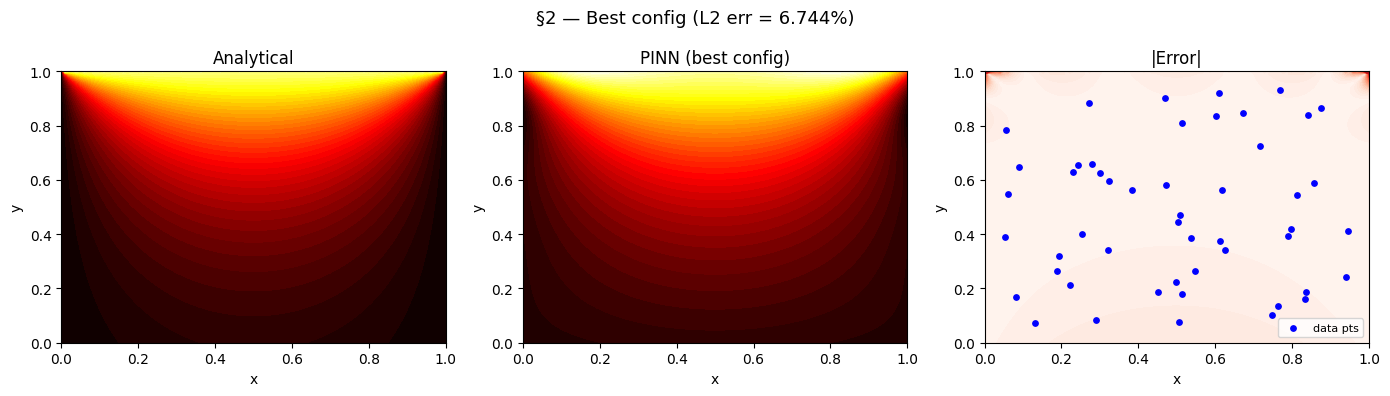

In [14]:
# ── Best config: Adam -> L-BFGS ────────────────────────────────────────────────
torch.manual_seed(42)
model_best = PINN(hidden=[64, 64, 64, 64], act = nn.GELU)
hist_best  = train_pinn(model_best, laplace_residual, bc_loss_p1,
                        n_epochs=5000, lr=1e-3,
                        data_pts=(X_DATA, Y_DATA, U_DATA), verbose=True)

_, _, U_best = eval_model(model_best)
err_best = np.abs(U_best - u_exact_p1(XX, YY))
l2_best  = l2_error(model_best, u_exact_p1)
print(f"\nBest config — Relative L2 error: {l2_best:.4%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(levels=50, cmap='hot')
axes[0].contourf(XX, YY, u_exact_p1(XX, YY), **kw); axes[0].set_title('Analytical')
axes[1].contourf(XX, YY, U_best, **kw);             axes[1].set_title('PINN (best config)')
c2 = axes[2].contourf(XX, YY, err_best, levels=50, cmap='Reds'); axes[2].set_title('|Error|')
axes[2].scatter(X_DATA.numpy(), Y_DATA.numpy(), c='blue', s=15, zorder=5, label='data pts')
axes[2].legend(loc='lower right', fontsize=8)
for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle(f'§2 — Best config (L2 err = {l2_best:.3%})', fontsize=13)
plt.tight_layout(); plt.show()


---
## 3. Triangle-Mesh Sampling

So far we sampled collocation points with `torch.rand()` — trivial on a box.
For **arbitrary geometries** we need a mesh-aware sampler.

### Strategy

Given a triangle mesh $(V, T)$:

1. Compute each triangle's area $A_k$.
2. Sample triangles proportional to $A_k$ (area-weighted).
3. For each sampled triangle, pick a random **barycentric** point:
   $$\mathbf{p} = (1-\sqrt{r_1})\,\mathbf{v}_0 + \sqrt{r_1}(1-r_2)\,\mathbf{v}_1 + r_2\sqrt{r_1}\,\mathbf{v}_2, \quad r_1,r_2 \sim U[0,1]$$

This gives **uniform coverage** regardless of triangle shape or size.

# ── Mesh generation helpers ────────────────────────────────────────────────────


In [ ]:
# ── Mesh sampling infrastructure ──────────────────────────────────────────────

def triangle_areas(verts, tris):
    '''Area of each triangle via cross-product formula.'''
    v0 = verts[tris[:, 0]]; v1 = verts[tris[:, 1]]; v2 = verts[tris[:, 2]]
    return 0.5 * np.abs((v1[:,0]-v0[:,0])*(v2[:,1]-v0[:,1])
                       -(v2[:,0]-v0[:,0])*(v1[:,1]-v0[:,1]))


def sample_mesh_interior(verts, tris, n):
    '''
    Sample n points uniformly from the interior of a triangle mesh
    using area-weighted triangle selection + barycentric coordinates.
    Returns (x, y) as float32 tensors.
    '''
    areas = triangle_areas(verts, tris)
    probs = areas / areas.sum()
    tri_idx = np.random.choice(len(tris), size=n, p=probs)
    r1 = np.random.rand(n); r2 = np.random.rand(n)
    s  = np.sqrt(r1)
    w0 = 1 - s;  w1 = s * (1 - r2);  w2 = s * r2
    tri_verts = verts[tris[tri_idx]]          # (n, 3, 2)
    pts = (w0[:,None]*tri_verts[:,0]
          + w1[:,None]*tri_verts[:,1]
          + w2[:,None]*tri_verts[:,2])
    return torch.tensor(pts[:,0], dtype=torch.float32), torch.tensor(pts[:,1], dtype=torch.float32)


def sample_boundary_segment(verts, v0_idx, v1_idx, n):
    '''Sample n uniform points along the segment between two vertices.'''
    t  = torch.rand(n)
    p0 = verts[v0_idx]; p1 = verts[v1_idx]
    x  = p0[0] + t.numpy() * (p1[0] - p0[0])
    y  = p0[1] + t.numpy() * (p1[1] - p0[1])
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def make_grid_mesh(nx, ny, x0=0.0, x1=1.0, y0=0.0, y1=1.0):
    '''
    Uniform triangular mesh on [x0,x1] x [y0,y1].
    Each rectangular cell → 2 triangles: 2*nx*ny triangles total.
    Returns (verts float32, tris int32).
    '''
    xs = np.linspace(x0, x1, nx + 1)
    ys = np.linspace(y0, y1, ny + 1)
    XX_m, YY_m = np.meshgrid(xs, ys)          # (ny+1, nx+1)
    verts = np.stack([XX_m.ravel(), YY_m.ravel()], axis=1).astype(np.float32)
    tris = []
    for j in range(ny):
        for i in range(nx):
            v00 = j * (nx+1) + i;      v10 = j * (nx+1) + (i+1)
            v01 = (j+1)*(nx+1) + i;    v11 = (j+1)*(nx+1) + (i+1)
            tris.append([v00, v10, v11])    # lower-right
            tris.append([v00, v11, v01])    # upper-left
    return verts, np.array(tris, dtype=np.int32)


def make_L_mesh(nx=20, ny=20):
    '''
    Fine triangular mesh for L-shape: [0,1]^2 minus (0.5,1] x (0.5,1].
    Triangles whose centroid falls in the removed quadrant are discarded.
    '''
    verts, tris = make_grid_mesh(nx, ny)
    centroids = verts[tris].mean(axis=1)      # (n_tris, 2)
    inside = ~((centroids[:, 0] > 0.5) & (centroids[:, 1] > 0.5))
    return verts, tris[inside]


In [15]:
# ── Unit square mesh — fine grid (20×20 grid → 800 triangles) ─────────────────
sq_verts, sq_tris = make_grid_mesh(nx=20, ny=20)
print(f"Square mesh: {len(sq_verts)} vertices, {len(sq_tris)} triangles")

# Verify uniform interior coverage
x_s, y_s = sample_mesh_interior(sq_verts, sq_tris, n=3000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Left: mesh wireframe (subsample for clarity)
axes[0].triplot(sq_verts[:,0], sq_verts[:,1], sq_tris, color='steelblue',
                lw=0.4, alpha=0.7)
axes[0].set_title(f'Mesh ({len(sq_tris)} triangles)'); axes[0].set_aspect('equal')
# Right: interior samples
axes[1].scatter(x_s.numpy(), y_s.numpy(), s=1, alpha=0.4, color='steelblue')
axes[1].set_title('Interior samples (n=3000)'); axes[1].set_aspect('equal')
plt.suptitle('§3 — Unit square mesh', fontsize=12)
plt.tight_layout(); plt.show()


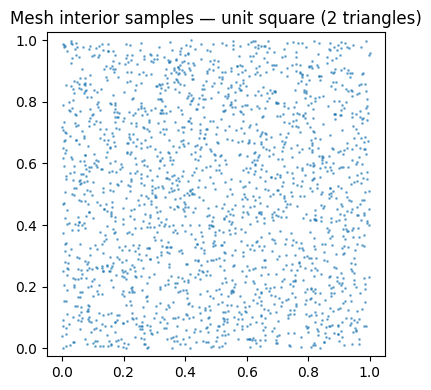

In [16]:
# ── Mesh-based BC sampler — coordinate-based, mesh-agnostic ───────────────────
def bc_loss_mesh_p1(model, n_per_edge=300):
    '''
    BC loss for §1: u=0 on left/right/bottom, u=1 on top.
    Samples boundary coordinates directly — works with any mesh resolution.
    '''
    losses = []
    for xi, yi, target in [
        (torch.rand(n_per_edge), torch.zeros(n_per_edge), 0.0),   # bottom
        (torch.rand(n_per_edge), torch.ones(n_per_edge),  1.0),   # top
        (torch.zeros(n_per_edge), torch.rand(n_per_edge), 0.0),   # left
        (torch.ones(n_per_edge),  torch.rand(n_per_edge), 0.0),   # right
    ]:
        pred = model(torch.stack([xi, yi], 1))
        losses.append((pred - target).pow(2).mean())
    return sum(losses) / len(losses)


# ── Mesh-aware PDE loss ────────────────────────────────────────────────────────
def laplace_residual_mesh(model, verts, tris, n=2000):
    '''Sample PDE collocation points from triangle mesh interior.'''
    x, y = sample_mesh_interior(verts, tris, n)
    return laplace_residual(model, x, y)


In [17]:
# ── Train PINN using mesh samplers ─────────────────────────────────────────────
torch.manual_seed(42)
model_mesh = PINN(hidden=[64, 64, 64, 64])
opt_mesh   = torch.optim.Adam(model_mesh.parameters(), lr=1e-3)

hist_mesh  = {'pde': [], 'bc': [], 'total': []}
W_PDE_M, W_BC_M = 1.0, 20.0
EPOCHS_MESH = 5000

for ep in range(1, EPOCHS_MESH+1):
    opt_mesh.zero_grad()
    lp   = laplace_residual_mesh(model_mesh, sq_verts, sq_tris, n=2000)
    lb   = bc_loss_mesh_p1(model_mesh, n_per_edge=300)
    loss = W_PDE_M*lp + W_BC_M*lb
    loss.backward(); opt_mesh.step()
    hist_mesh['pde'].append(lp.item())
    hist_mesh['bc'].append(lb.item())
    hist_mesh['total'].append(loss.item())
    if ep % 1000 == 0:
        print(f"Epoch {ep:5d} | pde {lp.item():.3e} | bc {lb.item():.3e}")

l2_mesh = l2_error(model_mesh, u_exact_p1)
print(f"\nMesh PINN — Relative L2 error: {l2_mesh:.4%}")


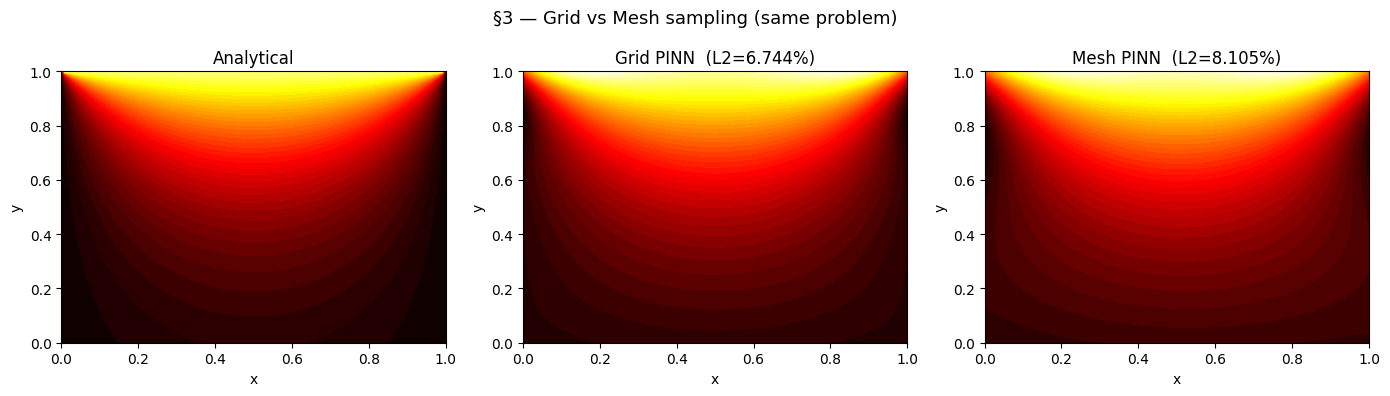

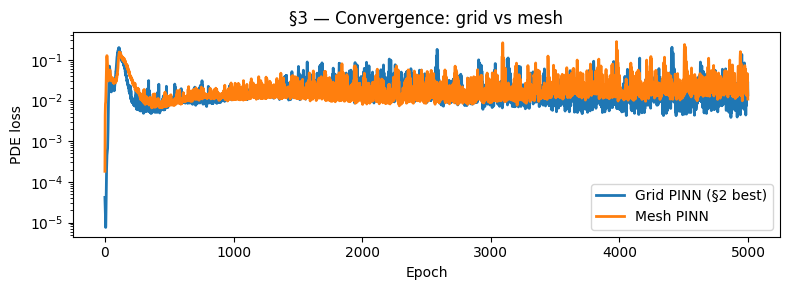

In [19]:
# ── Compare: grid sampler vs mesh sampler ──────────────────────────────────────
_, _, U_mesh = eval_model(model_mesh)
U_true_sq   = u_exact_p1(XX, YY)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(levels=50, cmap='hot')
axes[0].contourf(XX, YY, U_true_sq, **kw);       axes[0].set_title('Analytical')
axes[1].contourf(XX, YY, U_best, **kw);          axes[1].set_title(f'Grid PINN  (L2={l2_best:.3%})')
axes[2].contourf(XX, YY, U_mesh, **kw);          axes[2].set_title(f'Mesh PINN  (L2={l2_mesh:.3%})')
for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('§3 — Grid vs Mesh sampling (same problem)', fontsize=13)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,3))
ax.semilogy(hist_best['pde'],  label='Grid PINN (§2 best)', lw=2)
ax.semilogy(hist_mesh['pde'],  label='Mesh PINN', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('PDE loss'); ax.legend()
ax.set_title('§3 — Convergence: grid vs mesh')
plt.tight_layout(); plt.show()


---
## 4. Boundary Condition Variants

We keep the same domain and network, but change the BCs to explore how different
physical setups lead to qualitatively different temperature fields.

| Variant | BCs | Analytical |
|---------|-----|------------|
| **A** — Heated strip | $u = \sin(\pi x)$ on $y=0$, $u=0$ elsewhere | $\sin(\pi x)\sinh(\pi(1-y))/\sinh(\pi)$ |
| **B** — Insulated top (Neumann) | $u=\sin(\pi x)$ on $y=0$, $u=0$ on sides, $\partial u/\partial y=0$ on $y=1$ | $\sin(\pi x)\cosh(\pi(1-y))/\cosh(\pi)$ |
| **C** — Symmetric Neumann sides | $\partial u/\partial x=0$ on $x=0,1$; $u=0$ on $y=0$; $u=1$ on $y=1$ | $u=y$ |

Each variant has a clean analytical solution for benchmark comparison.


  Adam ep  1000 | pde 1.264e-03 | bc 9.004e-05
  Adam ep  2000 | pde 6.056e-04 | bc 2.472e-05
  Adam ep  3000 | pde 9.856e-04 | bc 3.996e-04
  Adam ep  4000 | pde 3.429e-04 | bc 9.550e-06
  Adam ep  5000 | pde 8.066e-04 | bc 1.499e-05
  L-BFGS step  100 | pde 2.114e-04 | bc 6.218e-06
  L-BFGS step  200 | pde 1.643e-04 | bc 6.482e-06

Variant A — L2 error: 0.4455%


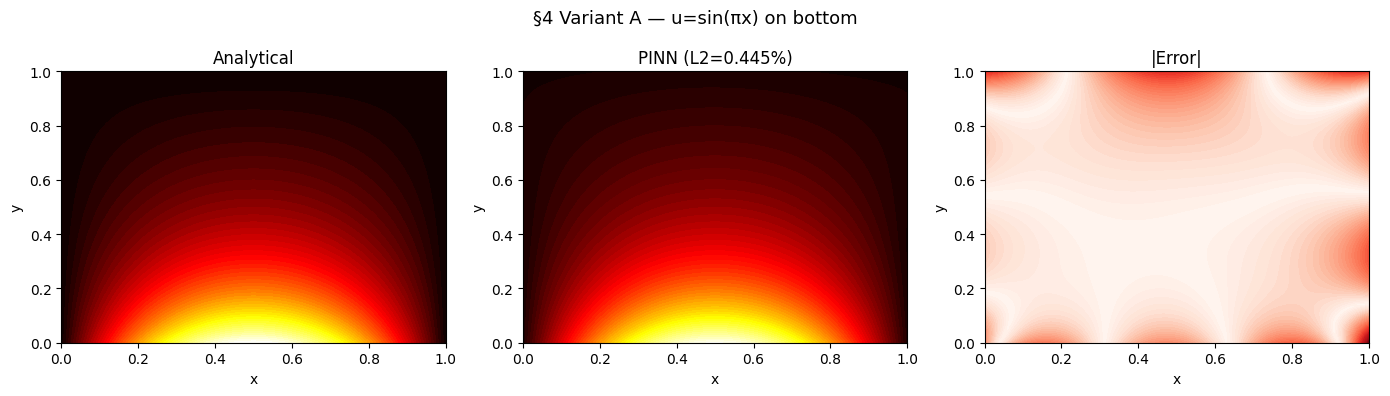

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Variant A — heated strip: u = sin(πx) on bottom, u=0 elsewhere
# Analytical: u = sin(πx) · sinh(π(1-y)) / sinh(π)
# ══════════════════════════════════════════════════════════════════════════════
def u_exact_A(x, y):
    return np.sin(np.pi * x) * np.sinh(np.pi * (1 - y)) / np.sinh(np.pi)

def bc_loss_A(model, n=300):
    losses = []
    # bottom: u = sin(πx)
    x = torch.rand(n); y = torch.zeros(n)
    target = torch.sin(torch.tensor(float(np.pi)) * x)
    losses.append((model(torch.stack([x,y],1)) - target).pow(2).mean())
    # left: u=0
    x = torch.zeros(n); y = torch.rand(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())
    # right: u=0
    x = torch.ones(n); y = torch.rand(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())
    # top: u=0
    x = torch.rand(n); y = torch.ones(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())
    return sum(losses) / len(losses)

torch.manual_seed(42)
model_A = PINN(hidden=[64,64,64,64])
hist_A  = train_pinn(model_A, laplace_residual, bc_loss_A,
                     n_epochs=5000, lbfgs_steps=200, verbose=True)
l2_A = l2_error(model_A, u_exact_A)
print(f"\nVariant A — L2 error: {l2_A:.4%}")

_, _, U_A   = eval_model(model_A)
U_true_A    = u_exact_A(XX, YY)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(levels=50, cmap='hot')
axes[0].contourf(XX, YY, U_true_A, **kw); axes[0].set_title('Analytical')
axes[1].contourf(XX, YY, U_A, **kw);      axes[1].set_title(f'PINN (L2={l2_A:.3%})')
axes[2].contourf(XX, YY, np.abs(U_A-U_true_A), levels=50, cmap='Reds'); axes[2].set_title('|Error|')
for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('§4 Variant A — u=sin(πx) on bottom', fontsize=13)
plt.tight_layout(); plt.show()


  Adam ep  1000 | pde 2.283e-03 | bc 1.007e-03
  Adam ep  2000 | pde 1.676e-03 | bc 3.867e-05
  Adam ep  3000 | pde 1.379e-03 | bc 8.898e-05
  Adam ep  4000 | pde 1.143e-03 | bc 1.791e-05
  Adam ep  5000 | pde 7.923e-04 | bc 1.738e-05
  L-BFGS step  100 | pde 6.535e-04 | bc 8.620e-06
  L-BFGS step  200 | pde 5.893e-04 | bc 8.567e-06

Variant B — L2 error: 0.3513%


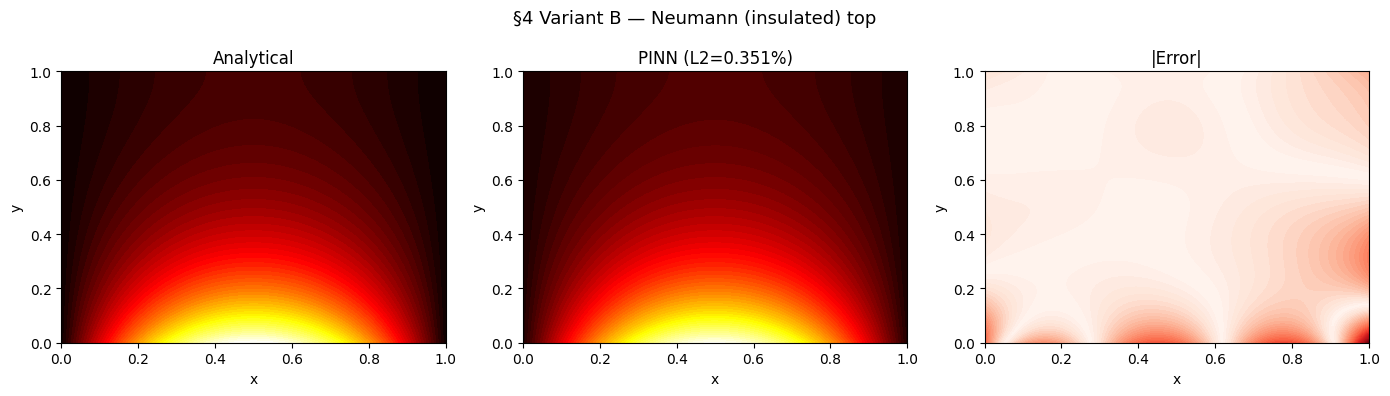

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Variant B — insulated top: ∂u/∂y = 0 at y=1
# Analytical: u = sin(πx) · cosh(π(1-y)) / cosh(π)
# ══════════════════════════════════════════════════════════════════════════════
def u_exact_B(x, y):
    return np.sin(np.pi * x) * np.cosh(np.pi * (1 - y)) / np.cosh(np.pi)

def neumann_top_loss(model, n=300):
    '''Enforce ∂u/∂y = 0 at y=1.'''
    x = torch.rand(n)
    y = torch.ones(n).requires_grad_(True)
    u = model(torch.stack([x, y], 1))
    u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]
    return u_y.pow(2).mean()

def bc_loss_B(model, n=300):
    losses = []
    # bottom: u = sin(πx)
    x = torch.rand(n); y = torch.zeros(n)
    losses.append((model(torch.stack([x,y],1)) - torch.sin(torch.tensor(float(np.pi))*x)).pow(2).mean())
    # left: u=0
    x = torch.zeros(n); y = torch.rand(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())
    # right: u=0
    x = torch.ones(n); y = torch.rand(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())
    # top: Neumann ∂u/∂y=0
    losses.append(neumann_top_loss(model, n))
    return sum(losses) / len(losses)

torch.manual_seed(42)
model_B = PINN(hidden=[64,64,64,64])
hist_B  = train_pinn(model_B, laplace_residual, bc_loss_B,
                     n_epochs=5000, lbfgs_steps=200, verbose=True)
l2_B = l2_error(model_B, u_exact_B)
print(f"\nVariant B — L2 error: {l2_B:.4%}")

_, _, U_B = eval_model(model_B)
U_true_B  = u_exact_B(XX, YY)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(levels=50, cmap='hot')
axes[0].contourf(XX, YY, U_true_B, **kw); axes[0].set_title('Analytical')
axes[1].contourf(XX, YY, U_B, **kw);      axes[1].set_title(f'PINN (L2={l2_B:.3%})')
axes[2].contourf(XX, YY, np.abs(U_B-U_true_B), levels=50, cmap='Reds'); axes[2].set_title('|Error|')
for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('§4 Variant B — Neumann (insulated) top', fontsize=13)
plt.tight_layout(); plt.show()


  Adam ep  1000 | pde 1.633e-04 | bc 9.527e-05
  Adam ep  2000 | pde 7.790e-05 | bc 3.193e-07
  Adam ep  3000 | pde 6.573e-05 | bc 1.941e-07
  Adam ep  4000 | pde 1.061e-04 | bc 1.695e-04
  Adam ep  5000 | pde 3.993e-05 | bc 3.590e-05
  L-BFGS step  100 | pde 1.001e-06 | bc 7.211e-09
  L-BFGS step  200 | pde 6.453e-07 | bc 7.654e-09

Variant C — L2 error: 0.0072%


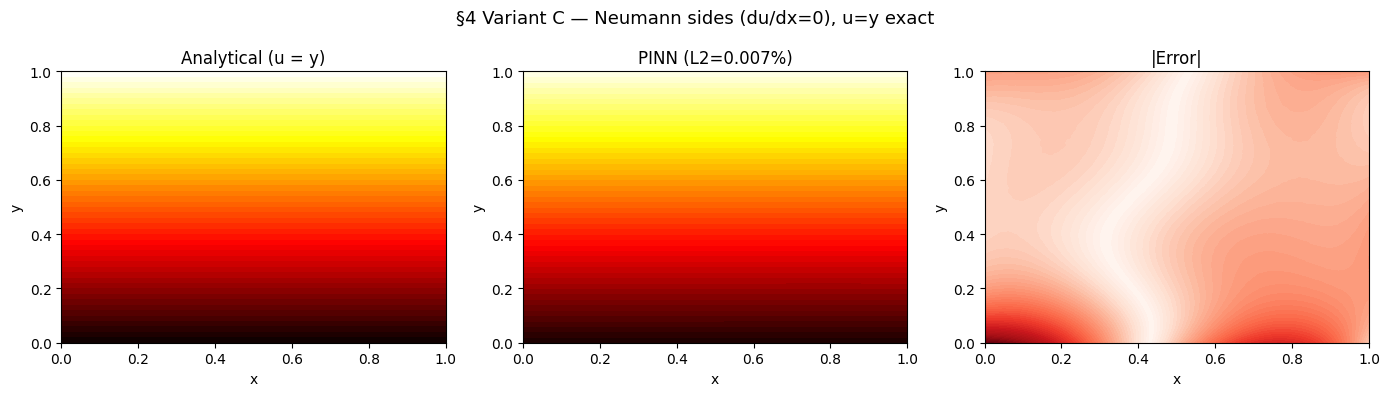

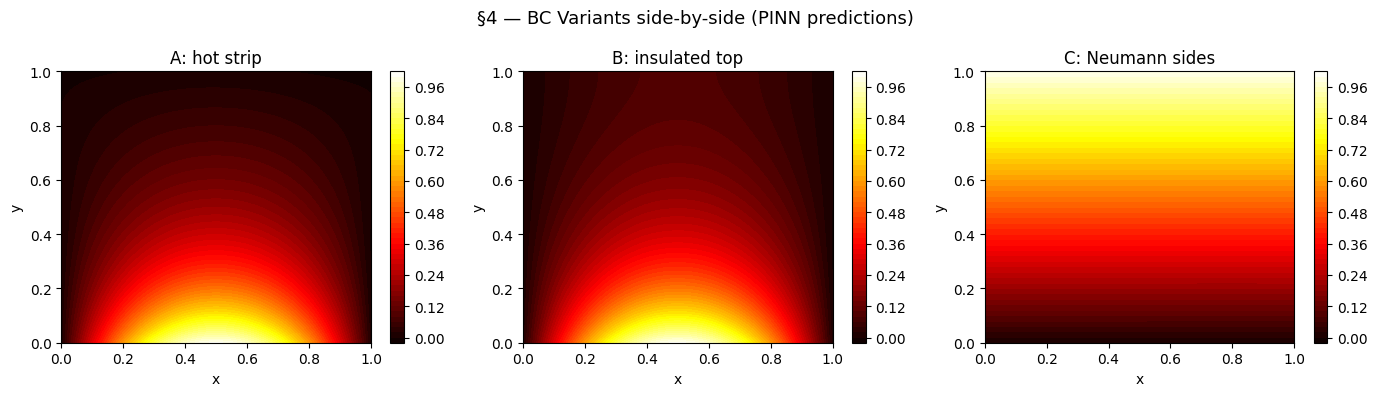

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Variant C — Neumann (insulated) sides: ∂u/∂x = 0 at x=0,1
# u=0 on bottom, u=1 on top.
# Analytical: u = y  (uniform linear gradient)
# Explanation: with ∂u/∂x=0 on sides, all sine modes vanish; only the
# n=0 cosine mode survives: u = y.
# ══════════════════════════════════════════════════════════════════════════════
def u_exact_C(x, y):
    return y   # trivially linear!

def neumann_sides_loss(model, n=300):
    '''Enforce ∂u/∂x = 0 at x=0 and x=1.'''
    y = torch.rand(n)
    # x=0
    x0 = torch.zeros(n).requires_grad_(True)
    u0 = model(torch.stack([x0, y], 1))
    u0_x = torch.autograd.grad(u0.sum(), x0, create_graph=True)[0]
    l0 = u0_x.pow(2).mean()
    # x=1
    x1 = torch.ones(n).requires_grad_(True)
    u1 = model(torch.stack([x1, y], 1))
    u1_x = torch.autograd.grad(u1.sum(), x1, create_graph=True)[0]
    l1 = u1_x.pow(2).mean()
    return (l0 + l1) / 2

def bc_loss_C(model, n=300):
    losses = []
    # bottom: u=0
    x = torch.rand(n); y = torch.zeros(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())
    # top: u=1
    x = torch.rand(n); y = torch.ones(n)
    losses.append((model(torch.stack([x,y],1)) - 1).pow(2).mean())
    # sides: Neumann
    losses.append(neumann_sides_loss(model, n))
    return sum(losses) / len(losses)

torch.manual_seed(42)
model_C = PINN(hidden=[64,64,64,64])
hist_C  = train_pinn(model_C, laplace_residual, bc_loss_C,
                     n_epochs=5000, lbfgs_steps=200, verbose=True)
l2_C = l2_error(model_C, lambda x, y: np.ones_like(x) * y)
print(f"\nVariant C — L2 error: {l2_C:.4%}")

_, _, U_C = eval_model(model_C)
U_true_C  = YY  # u=y
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(levels=50, cmap='hot')
axes[0].contourf(XX, YY, U_true_C, **kw); axes[0].set_title('Analytical (u = y)')
axes[1].contourf(XX, YY, U_C, **kw);      axes[1].set_title(f'PINN (L2={l2_C:.3%})')
axes[2].contourf(XX, YY, np.abs(U_C-U_true_C), levels=50, cmap='Reds'); axes[2].set_title('|Error|')
for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('§4 Variant C — Neumann sides (du/dx=0), u=y exact', fontsize=13)
plt.tight_layout(); plt.show()

# Side-by-side summary
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (U, title) in zip(axes, [(U_A,'A: hot strip'),(U_B,'B: insulated top'),(U_C,'C: Neumann sides')]):
    c = ax.contourf(XX, YY, U, levels=50, cmap='hot')
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(c, ax=ax)
plt.suptitle('§4 — BC Variants side-by-side (PINN predictions)', fontsize=13)
plt.tight_layout(); plt.show()


---
## 5. L-Shaped Domain

The L-shape is the canonical test case for PDE solvers on non-convex domains.
A **270° re-entrant corner** at $(0.5, 0.5)$ creates a stress concentration where
the solution gradient becomes singular — challenging for mesh-free methods.

**Problem:** Laplace equation on the L-shape, zero Dirichlet on all boundaries,
with a source-like BC: $u=\sin(\pi x)$ applied on the bottom edge.

Since there is no simple closed-form, we use a **finite-difference reference** on
a fine grid for comparison.


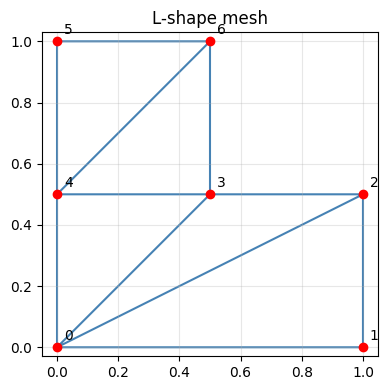

Mesh area: 0.7500  (expected 0.75)


In [24]:
# ── L-shape mesh — fine grid (20×20 base → ~600 triangles after masking) ──────
#
#  (0,1)──(0.5,1)
#    |        |
#  (0,.5)─(.5,.5)────(1,0.5)
#    |                  |
#  (0,0)─────────────(1,0)
#
L_verts, L_tris = make_L_mesh(nx=20, ny=20)
print(f"L-shape mesh: {len(L_verts)} vertices, {len(L_tris)} triangles")

# Verify area = 0.75 (three quadrants of the unit square)
areas = triangle_areas(L_verts, L_tris)
print(f"Mesh area:    {areas.sum():.4f}  (expected 0.75)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].triplot(L_verts[:,0], L_verts[:,1], L_tris, color='steelblue', lw=0.4, alpha=0.7)
axes[0].set_title(f'L-shape mesh ({len(L_tris)} triangles)')
axes[0].set_aspect('equal'); axes[0].set_xlim(-0.05, 1.05); axes[0].set_ylim(-0.05, 1.05)

x_L, y_L = sample_mesh_interior(L_verts, L_tris, n=3000)
axes[1].scatter(x_L.numpy(), y_L.numpy(), s=1, alpha=0.4, color='steelblue')
axes[1].set_title('Interior samples (n=3000)'); axes[1].set_aspect('equal')
plt.suptitle('§5 — L-shaped domain mesh', fontsize=12)
plt.tight_layout(); plt.show()


Computing FD reference (may take a few seconds)...
Done.


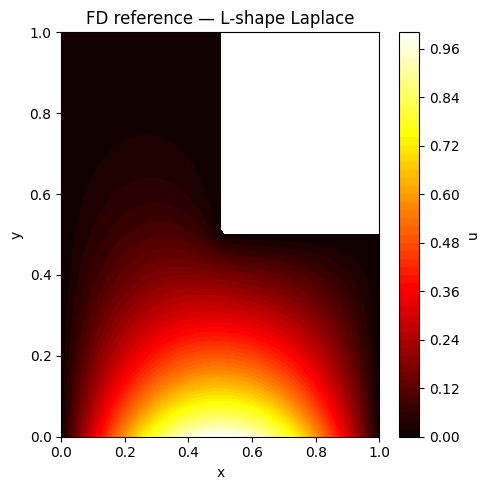

In [25]:
# ── Finite-difference reference solution ───────────────────────────────────────
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def fd_laplace_L(N=100):
    '''
    Finite-difference solution of Laplace on L-shape.
    Grid: uniform NxN on [0,1]^2, interior of L-shape only.
    BCs: u=sin(pi*x) on bottom edge, u=0 elsewhere.
    '''
    h  = 1.0 / N
    xs = np.linspace(0, 1, N+1)
    ys = np.linspace(0, 1, N+1)

    def in_L(i, j):  # (i=col->x, j=row->y)
        x = xs[i]; y = ys[j]
        return (x <= 0.5 or y <= 0.5) and (0 <= x <= 1) and (0 <= y <= 1)

    def on_boundary(i, j):
        x = xs[i]; y = ys[j]
        if i == 0 or j == 0 or (i == N and y <= 0.5) or (j == N and x <= 0.5):
            return True
        if abs(x - 0.5) < 1e-12 and y >= 0.5 - 1e-12:
            return True
        if abs(y - 0.5) < 1e-12 and x >= 0.5 - 1e-12:
            return True
        if i == N or j == N:
            return True
        return False

    def bc_val(i, j):
        x = xs[i]; y = ys[j]
        if j == 0:  # bottom
            return np.sin(np.pi * x)
        return 0.0

    # Index only L-shape interior nodes
    idx = {}
    interior = []
    for j in range(N+1):
        for i in range(N+1):
            if in_L(i,j) and not on_boundary(i,j):
                idx[(i,j)] = len(interior)
                interior.append((i,j))

    n_int = len(interior)
    A = lil_matrix((n_int, n_int))
    b = np.zeros(n_int)

    for k, (i,j) in enumerate(interior):
        A[k, k] = 4.0
        for di, dj in [(1,0),(-1,0),(0,1),(0,-1)]:
            ni, nj = i+di, j+dj
            if in_L(ni, nj):
                if on_boundary(ni, nj):
                    b[k] += bc_val(ni, nj)
                else:
                    A[k, idx[(ni,nj)]] = -1.0

    u_vals = spsolve(A.tocsr(), b)

    # Build full grid (NaN outside L)
    U = np.full((N+1, N+1), np.nan)
    for k, (i,j) in enumerate(interior):
        U[j, i] = u_vals[k]
    for j in range(N+1):
        for i in range(N+1):
            if in_L(i,j) and on_boundary(i,j):
                U[j,i] = bc_val(i,j)

    return xs, ys, U

print("Computing FD reference (may take a few seconds)...")
xs_fd, ys_fd, U_fd = fd_laplace_L(N=80)
print("Done.")

plt.figure(figsize=(5, 5))
plt.contourf(xs_fd, ys_fd, U_fd, levels=50, cmap='hot')
plt.colorbar(label='u')
plt.title('FD reference — L-shape Laplace')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()


In [26]:
# ── BC loss for L-shape ────────────────────────────────────────────────────────
def bc_loss_L(model, n=300):
    '''
    u = sin(pi*x) on bottom (y=0, 0<=x<=1)
    u = 0 on all other boundary segments.
    '''
    losses = []

    # Bottom (y=0): u = sin(pi*x)
    x = torch.rand(n); y = torch.zeros(n)
    losses.append((model(torch.stack([x,y],1)) - torch.sin(torch.tensor(float(np.pi))*x)).pow(2).mean())

    # Left edge (x=0, 0<=y<=1)
    x = torch.zeros(n); y = torch.rand(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())

    # Right edge (x=1, 0<=y<=0.5)
    x = torch.ones(n); y = torch.rand(n) * 0.5
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())

    # Bottom of notch (y=0.5, 0.5<=x<=1)
    x = torch.rand(n)*0.5 + 0.5; y = torch.ones(n)*0.5
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())

    # Right of notch (x=0.5, 0.5<=y<=1)
    x = torch.ones(n)*0.5; y = torch.rand(n)*0.5 + 0.5
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())

    # Top edge (y=1, 0<=x<=0.5)
    x = torch.rand(n)*0.5; y = torch.ones(n)
    losses.append(model(torch.stack([x,y],1)).pow(2).mean())

    return sum(losses) / len(losses)


def laplace_residual_L(model, n=2000):
    x, y = sample_mesh_interior(L_verts, L_tris, n)
    return laplace_residual(model, x, y)


# ── Train ───────────────────────────────────────────────────────────────────────
torch.manual_seed(42)
model_L = PINN(hidden=[64, 64, 64, 64])
opt_L   = torch.optim.Adam(model_L.parameters(), lr=1e-3)
sched_L = torch.optim.lr_scheduler.CosineAnnealingLR(opt_L, T_max=6000)

hist_L  = {'pde': [], 'bc': [], 'total': []}
EPOCHS_L = 6000

for ep in range(1, EPOCHS_L+1):
    opt_L.zero_grad()
    lp   = laplace_residual_L(model_L)
    lb   = bc_loss_L(model_L)
    loss = 1.0*lp + 20.0*lb
    loss.backward(); opt_L.step(); sched_L.step()
    hist_L['pde'].append(lp.item())
    hist_L['bc'].append(lb.item())
    hist_L['total'].append(loss.item())
    if ep % 1000 == 0:
        print(f"Epoch {ep:5d} | pde {lp.item():.3e} | bc {lb.item():.3e}")

# L-BFGS fine-tune
opt_lbfgs_L = torch.optim.LBFGS(model_L.parameters(), lr=0.5, max_iter=20,
                                  history_size=50, line_search_fn='strong_wolfe')
for step in range(300):
    def closure_L():
        opt_lbfgs_L.zero_grad()
        loss = 1.0*laplace_residual_L(model_L) + 20.0*bc_loss_L(model_L)
        loss.backward(); return loss
    opt_lbfgs_L.step(closure_L)

print("L-BFGS fine-tuning done.")


Epoch  1000 | pde 9.113e-03 | bc 2.559e-03
Epoch  2000 | pde 4.719e-03 | bc 2.059e-03
Epoch  3000 | pde 4.885e-03 | bc 1.742e-03
Epoch  4000 | pde 3.695e-03 | bc 1.337e-03
Epoch  5000 | pde 3.460e-03 | bc 1.245e-03
Epoch  6000 | pde 3.010e-03 | bc 1.151e-03
L-BFGS fine-tuning done.


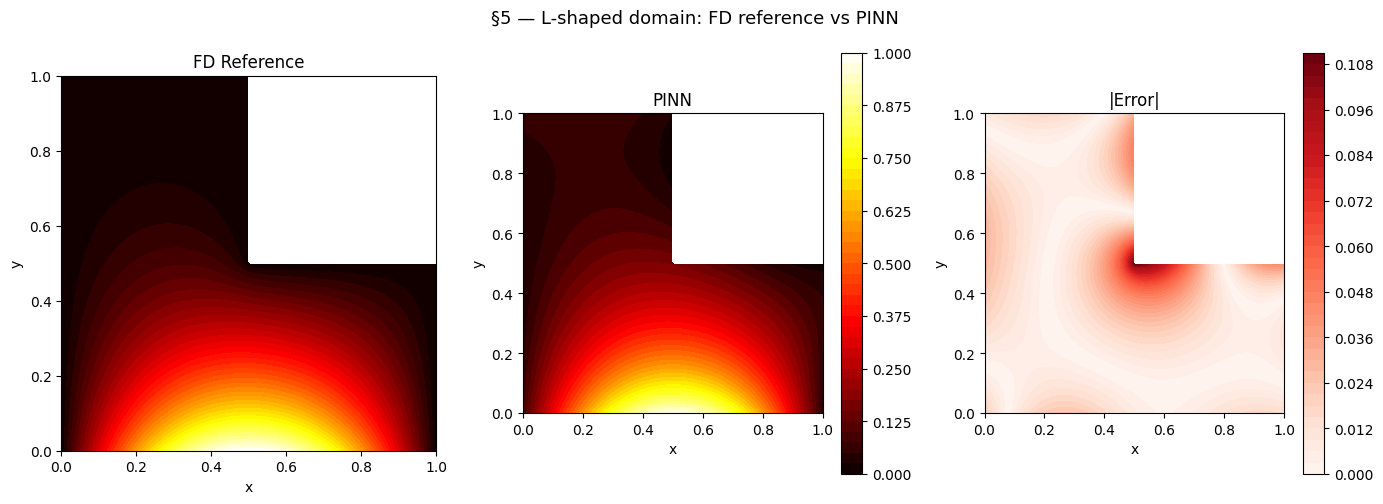

RMSE vs FD reference: 0.01913


In [27]:
# ── Evaluate PINN on L-shape ────────────────────────────────────────────────────
N_ev = 120
x1d_ev = np.linspace(0, 1, N_ev)
y1d_ev = np.linspace(0, 1, N_ev)
XX_ev, YY_ev = np.meshgrid(x1d_ev, y1d_ev)

def in_L_np(x, y):
    return (x <= 0.5) | (y <= 0.5)

mask = in_L_np(XX_ev, YY_ev)

xy_ev = torch.tensor(np.stack([XX_ev.ravel(), YY_ev.ravel()], 1), dtype=torch.float32)
with torch.no_grad():
    U_pinn_L = model_L(xy_ev).numpy().reshape(N_ev, N_ev)
U_pinn_L[~mask] = np.nan

# Interpolate FD solution to same grid for comparison
from scipy.interpolate import RegularGridInterpolator
fd_interp = RegularGridInterpolator((ys_fd, xs_fd), np.nan_to_num(U_fd, nan=0.0),
                                     method='linear', bounds_error=False, fill_value=np.nan)
pts = np.stack([YY_ev.ravel(), XX_ev.ravel()], axis=1)
U_fd_ev = fd_interp(pts).reshape(N_ev, N_ev)
U_fd_ev[~mask] = np.nan

err_L = np.abs(U_pinn_L - U_fd_ev)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
kw = dict(levels=40, cmap='hot')
im0 = axes[0].contourf(XX_ev, YY_ev, U_fd_ev,   **kw); axes[0].set_title('FD Reference')
im1 = axes[1].contourf(XX_ev, YY_ev, U_pinn_L,  **kw); axes[1].set_title('PINN')
im2 = axes[2].contourf(XX_ev, YY_ev, err_L, levels=40, cmap='Reds'); axes[2].set_title('|Error|')
for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
fig.colorbar(im0, ax=axes[1]); fig.colorbar(im2, ax=axes[2])
plt.suptitle('§5 — L-shaped domain: FD reference vs PINN', fontsize=13)
plt.tight_layout(); plt.show()

# Error stats (inside L only)
valid = mask & ~np.isnan(U_fd_ev) & ~np.isnan(U_pinn_L)
mse_L = np.sqrt(((U_pinn_L[valid] - U_fd_ev[valid])**2).mean())
print(f"RMSE vs FD reference: {mse_L:.5f}")


---
## 6. Transient Heat Equation

We now add time, solving:

$$\frac{\partial u}{\partial t} = \alpha \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right), \quad (x,y)\in[0,1]^2,\; t\in[0,T]$$

**Setup:**

| | |
|---|---|
| $\alpha$ | 1.0 (thermal diffusivity) |
| IC | $u(x,y,0) = \sin(\pi x)\sin(\pi y)$ |
| BC | $u=0$ on all boundaries |
| $T$ | 0.5 |

**Analytical solution** (separation of variables):

$$u(x,y,t) = e^{-2\pi^2 \alpha t}\,\sin(\pi x)\,\sin(\pi y)$$

This decays exponentially in time — a clean benchmark.

**Network:** $\hat u_\theta(x,y,t)$ — 3 inputs now, same MLP architecture.


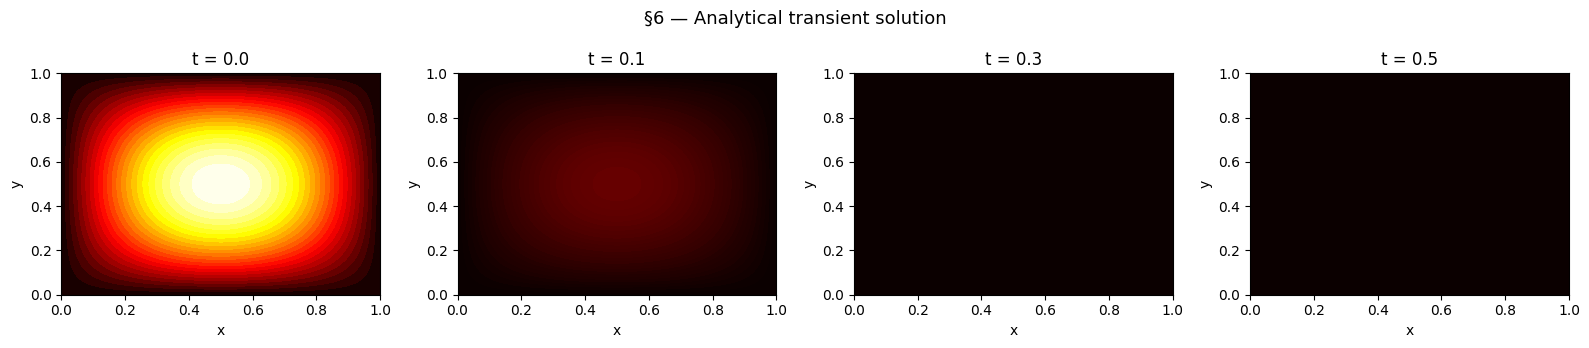

In [28]:
ALPHA = 1.0
T_END = 0.5

def u_exact_transient(x, y, t, alpha=ALPHA):
    '''Exact solution: exp(-2*pi^2*alpha*t)*sin(pi*x)*sin(pi*y).'''
    return np.exp(-2 * np.pi**2 * alpha * t) * np.sin(np.pi * x) * np.sin(np.pi * y)

# Visualise at a few time slices
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
x1d = np.linspace(0, 1, 80); y1d = np.linspace(0, 1, 80)
XX2, YY2 = np.meshgrid(x1d, y1d)
for ax, t_val in zip(axes, [0.0, 0.1, 0.3, 0.5]):
    U_t = u_exact_transient(XX2, YY2, t_val)
    c = ax.contourf(XX2, YY2, U_t, levels=30, cmap='hot', vmin=0, vmax=1)
    ax.set_title(f't = {t_val}'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('§6 — Analytical transient solution', fontsize=13)
plt.tight_layout(); plt.show()


In [29]:
# ── Transient PDE loss ─────────────────────────────────────────────────────────
def heat_residual(model, x, y, t, alpha=ALPHA):
    '''Residual of u_t - alpha*(u_xx + u_yy) at interior space-time points.'''
    x = x.clone().requires_grad_(True)
    y = y.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    xyt = torch.stack([x, y, t], dim=1)
    u = model(xyt)
    u_t  = torch.autograd.grad(u.sum(), t, create_graph=True)[0]
    u_x  = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
    u_y  = torch.autograd.grad(u.sum(), y, create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y.sum(), y, create_graph=True)[0]
    residual = u_t - alpha * (u_xx + u_yy)
    return residual.pow(2).mean()

def ic_loss(model, n=500):
    '''IC: u(x,y,0) = sin(pi*x)*sin(pi*y).'''
    x = torch.rand(n); y = torch.rand(n); t = torch.zeros(n)
    pred = model(torch.stack([x, y, t], 1))
    pi_t = torch.tensor(float(np.pi))
    target = torch.sin(pi_t*x) * torch.sin(pi_t*y)
    return (pred - target).pow(2).mean()

def bc_loss_transient(model, n=200):
    '''u=0 on all 4 walls for all t.'''
    losses = []
    t = torch.rand(n) * T_END
    for xi, yi in [(torch.zeros(n), torch.rand(n)),   # left
                   (torch.ones(n),  torch.rand(n)),   # right
                   (torch.rand(n),  torch.zeros(n)),  # bottom
                   (torch.rand(n),  torch.ones(n))]:  # top
        losses.append(model(torch.stack([xi, yi, t], 1)).pow(2).mean())
    return sum(losses) / len(losses)


In [30]:
# ── Train transient PINN ────────────────────────────────────────────────────────
torch.manual_seed(42)
model_T = PINN(n_in=3, hidden=[64, 64, 64, 64])   # 3 inputs: x, y, t

# Phase 1: Adam
opt_T   = torch.optim.Adam(model_T.parameters(), lr=1e-3)
sched_T = torch.optim.lr_scheduler.CosineAnnealingLR(opt_T, T_max=6000)
hist_T  = {'pde': [], 'ic': [], 'bc': [], 'total': []}
W_PDE_T, W_IC_T, W_BC_T = 1.0, 20.0, 20.0
EPOCHS_T = 6000

for ep in range(1, EPOCHS_T+1):
    opt_T.zero_grad()
    x_i = torch.rand(2000); y_i = torch.rand(2000); t_i = torch.rand(2000)*T_END
    lp = heat_residual(model_T, x_i, y_i, t_i)
    li = ic_loss(model_T, 500)
    lb = bc_loss_transient(model_T, 200)
    loss = W_PDE_T*lp + W_IC_T*li + W_BC_T*lb
    loss.backward(); opt_T.step(); sched_T.step()
    hist_T['pde'].append(lp.item()); hist_T['ic'].append(li.item())
    hist_T['bc'].append(lb.item()); hist_T['total'].append(loss.item())
    if ep % 1000 == 0:
        print(f"Epoch {ep:5d} | pde {lp.item():.3e} | ic {li.item():.3e} | bc {lb.item():.3e}")

# Phase 2: L-BFGS
opt_lbfgs_T = torch.optim.LBFGS(model_T.parameters(), lr=0.5, max_iter=20,
                                  history_size=50, line_search_fn='strong_wolfe')
for step in range(300):
    def closure_T():
        opt_lbfgs_T.zero_grad()
        x_i = torch.rand(2000); y_i = torch.rand(2000); t_i = torch.rand(2000)*T_END
        lp = heat_residual(model_T, x_i, y_i, t_i)
        li = ic_loss(model_T, 500)
        lb = bc_loss_transient(model_T, 200)
        loss = W_PDE_T*lp + W_IC_T*li + W_BC_T*lb
        loss.backward(); return loss
    opt_lbfgs_T.step(closure_T)
    if (step+1) % 100 == 0:
        # heat_residual needs autograd — cannot use torch.no_grad()
        lp = heat_residual(model_T, torch.rand(500), torch.rand(500), torch.rand(500)*T_END)
        print(f"  L-BFGS {step+1:4d} | pde {lp.item():.3e}")

print("\nTraining complete.")


Epoch  1000 | pde 1.715e-02 | ic 1.314e-03 | bc 3.832e-04
Epoch  2000 | pde 6.038e-03 | ic 2.055e-04 | bc 1.632e-04
Epoch  3000 | pde 4.028e-03 | ic 6.405e-05 | bc 8.182e-05
Epoch  4000 | pde 4.759e-03 | ic 3.983e-05 | bc 7.169e-05
Epoch  5000 | pde 1.227e-03 | ic 2.345e-05 | bc 4.801e-05
Epoch  6000 | pde 1.901e-03 | ic 2.314e-05 | bc 3.277e-05


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
# ── Evaluate at time snapshots ─────────────────────────────────────────────────
def eval_transient(model, t_val, nx=80):
    x1d = np.linspace(0, 1, nx); y1d = np.linspace(0, 1, nx)
    XX_t, YY_t = np.meshgrid(x1d, y1d)
    t_arr = np.full(nx*nx, t_val, dtype=np.float32)
    xyt = torch.tensor(np.stack([XX_t.ravel(), YY_t.ravel(), t_arr], 1), dtype=torch.float32)
    with torch.no_grad():
        U_p = model(xyt).numpy().reshape(nx, nx)
    U_e = u_exact_transient(XX_t, YY_t, t_val)
    return XX_t, YY_t, U_p, U_e

t_snaps = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
fig, axes = plt.subplots(3, len(t_snaps), figsize=(18, 9))
errs = {}
for col, t_val in enumerate(t_snaps):
    XX_t, YY_t, U_p, U_e = eval_transient(model_T, t_val)
    err = np.abs(U_p - U_e)
    errs[t_val] = np.sqrt(((U_p-U_e)**2).mean()) / (np.sqrt((U_e**2).mean()) + 1e-12)
    kw = dict(levels=30, cmap='hot', vmin=0, vmax=1)
    axes[0,col].contourf(XX_t, YY_t, U_e, **kw); axes[0,col].set_title(f't={t_val}')
    axes[1,col].contourf(XX_t, YY_t, U_p, **kw)
    axes[2,col].contourf(XX_t, YY_t, err, levels=30, cmap='Reds')
    for ax in axes[:, col]: ax.set_xticks([]); ax.set_yticks([])

axes[0,0].set_ylabel('Analytical', fontsize=10)
axes[1,0].set_ylabel('PINN',       fontsize=10)
axes[2,0].set_ylabel('|Error|',    fontsize=10)
plt.suptitle('§6 — Transient PINN: snapshots', fontsize=13)
plt.tight_layout(); plt.show()

print("\nRelative L2 error by time snapshot:")
for t_val, e in errs.items():
    bar = chr(0x2588) * int(e * 500)
    print(f"  t={t_val:.2f}  {e:.4%}  {bar}")

# Loss curves
fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(hist_T['pde'],   label='PDE loss')
ax.semilogy(hist_T['ic'],    label='IC loss')
ax.semilogy(hist_T['bc'],    label='BC loss')
ax.semilogy(hist_T['total'], label='Total', lw=2)
ax.set_xlabel('Epoch'); ax.legend(ncol=4)
ax.set_title('§6 — Transient training history')
plt.tight_layout(); plt.show()
